# Assignment 3: Data preprocessing of historical tropical cyclone records

## Kira Wiesinger

In this assignment you will explore and preprocess a global collection of tropical cyclone
records, the International Best Track Archive for Climate Stewardship
[(IBTrACS)](https://www.ncei.noaa.gov/products/international-best-track-archive). The column
descriptions are given
[here](https://www.ncei.noaa.gov/sites/default/files/2025-09/IBTrACS_v04r01_column_documentation.pdf).
IBTrACS is the World Meteorological Organization's official archive of global tropical cyclone
tracks, assembled from every regional forecast centre. It is real operational data, which means it
is messy: reporting practices differ by basin and have changed over time.

The five parts follow the Weeks 2 and 3 material: look at the data, handle missing values, scale,
encode, and split. Assignment 4 models the same records once they are clean.

Answer each numbered question in the empty cell below it.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load and aggregate the data set
Using the following code, load in the data set (this takes a few seconds to run: the full archive is a large file):


In [2]:
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})

This data set includes cyclone tracks (so it has multiple entries per named cyclone). We'll use the code below to create an aggregated data set for only the named cyclones, which has one entry per cyclone. You will use the data set `dfnamed` for the rest of the assignment.

In [3]:
dfnamed = df.groupby("NAME").agg(MAX_WIND=('WMO_WIND','max'),
                               MIN_PRES=('WMO_PRES','min'),
                               MEAN_LAT=('LAT','mean'),
                               MEAN_LON=('LON','mean'),
                               BASIN=('BASIN','first'),
                               SUBBASIN=('SUBBASIN','first'),
                               NATURE=('NATURE','first'),
                               SEASON=('SEASON','first')).reset_index()
dfnamed.head()

# these lines of code remove the initial dataframe (we won't need it anymore)
import gc
del df
gc.collect()

0

## Part 1: Data Exploration

How many named cyclones are there?

In [4]:
len(dfnamed)

1909

1) Use the `pandas` `hist` method to plot the marginal distributions of the variables in the dataframe `dfnamed`

array([[<Axes: title={'center': 'MAX_WIND'}>,
        <Axes: title={'center': 'MIN_PRES'}>],
       [<Axes: title={'center': 'MEAN_LAT'}>,
        <Axes: title={'center': 'MEAN_LON'}>],
       [<Axes: title={'center': 'SEASON'}>, <Axes: >]], dtype=object)

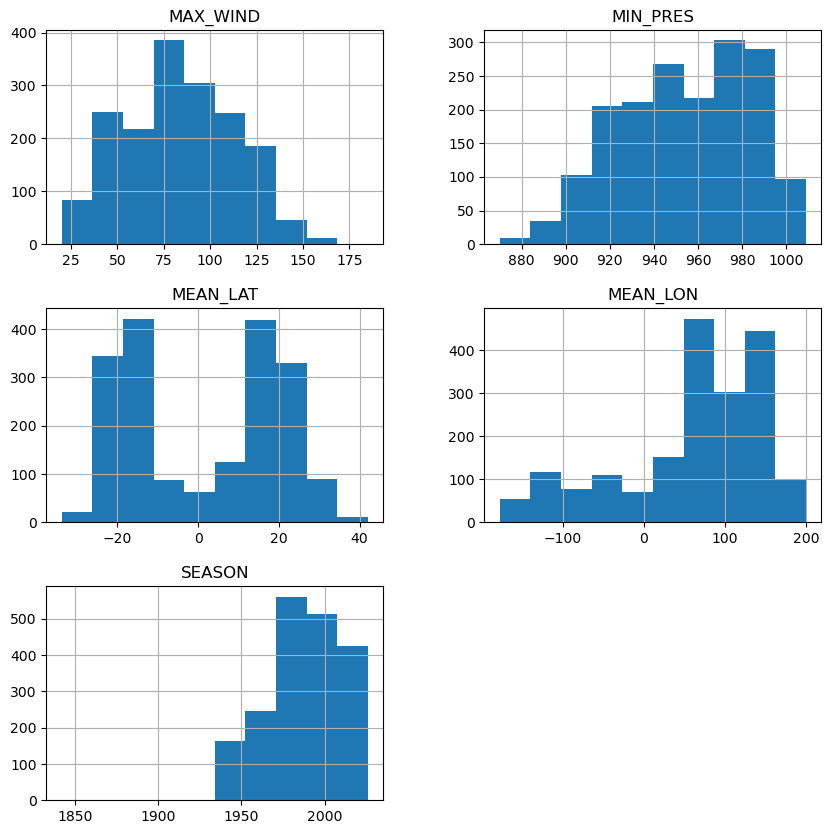

In [5]:
dfnamed.hist(figsize=(10, 10))

2) Use the `seaborn` Pairgrid function to create a scatterplot of all of the variables

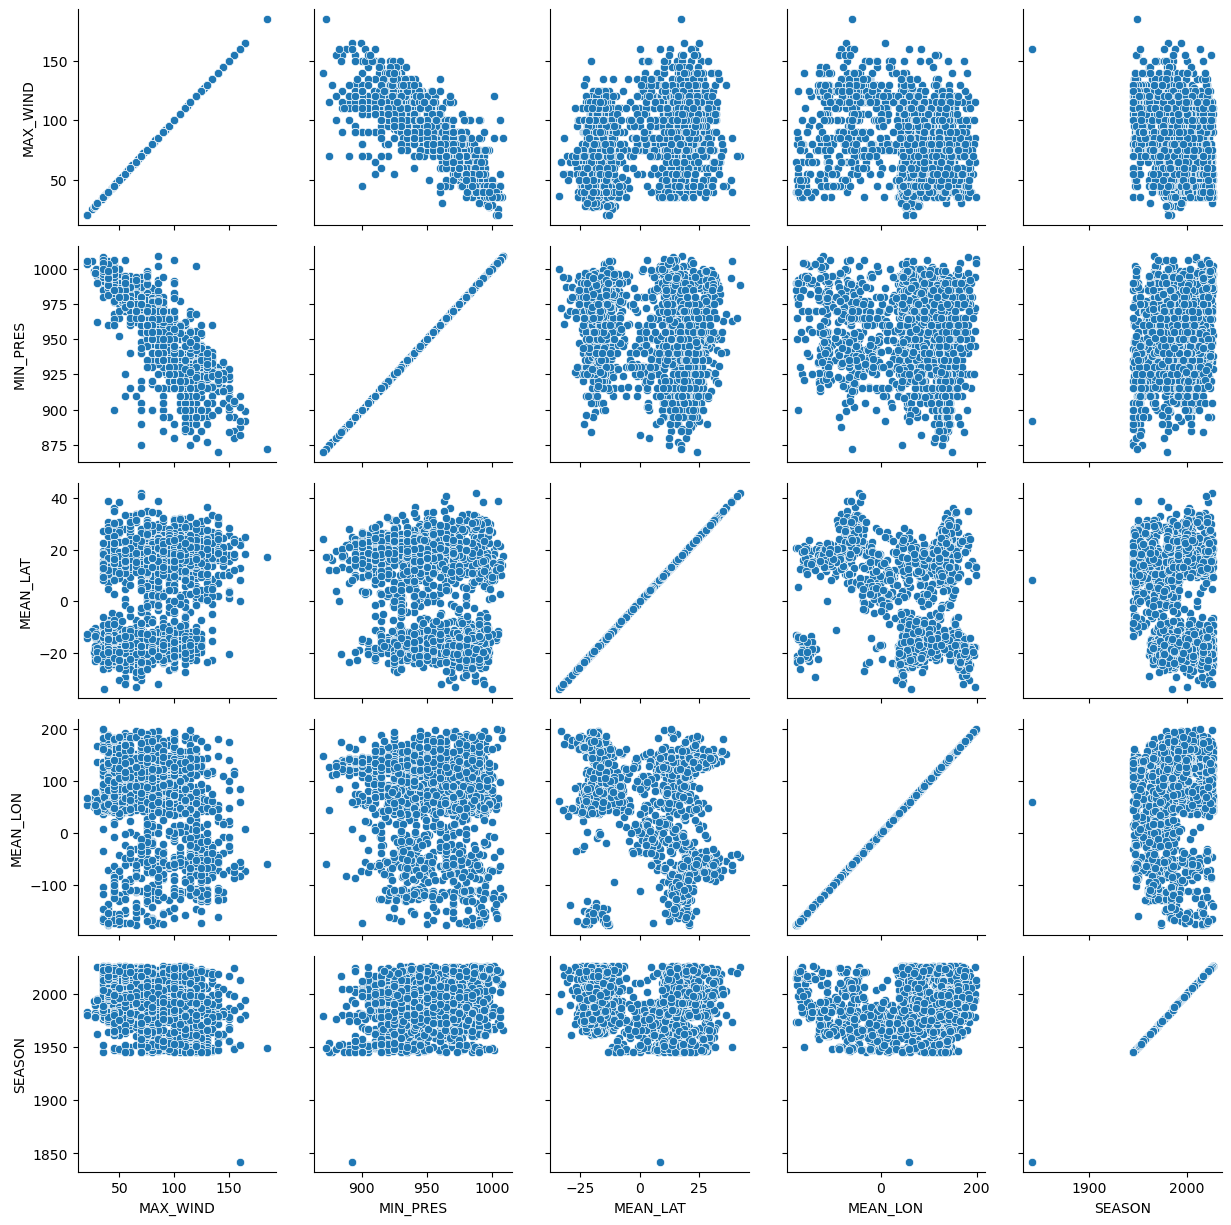

In [6]:
import seaborn as sns

g = sns.PairGrid(dfnamed)
g.map(sns.scatterplot)

3) Using `matplotlib`, create a scatter plot of the minimum pressure vs. the maximum wind speed and color by the year the cyclone took place.

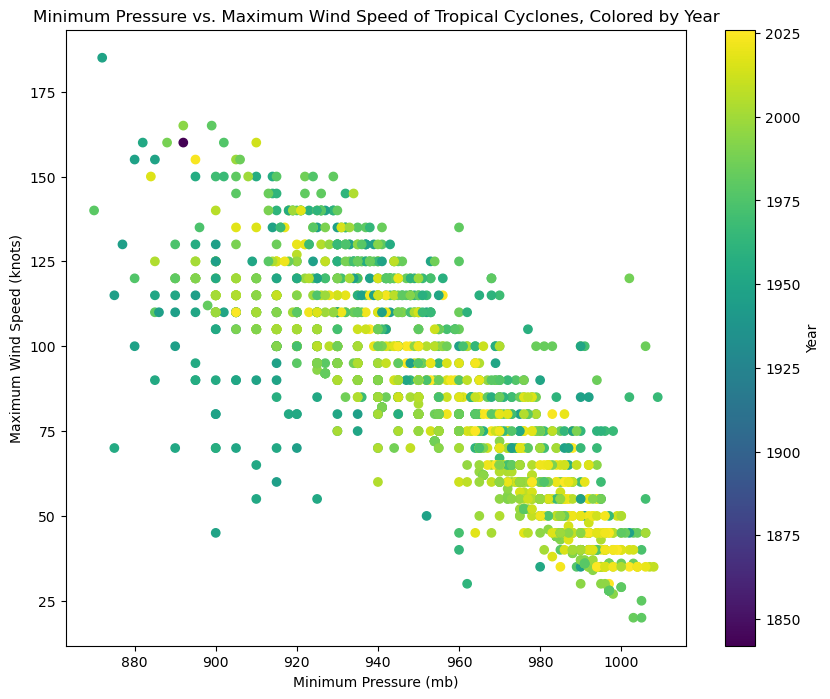

In [7]:
fig, ax = plt.subplots(figsize=(10,8))
scatter = ax.scatter(dfnamed["MIN_PRES"], dfnamed["MAX_WIND"], c=dfnamed["SEASON"])
cbar = fig.colorbar(scatter, label = "Year")

plt.title("Minimum Pressure vs. Maximum Wind Speed of Tropical Cyclones, Colored by Year")
plt.xlabel("Minimum Pressure (mb)")
plt.ylabel("Maximum Wind Speed (knots)")

plt.show()

## Part 2: Handle missing data
4) How many non-null values does each variable have?

In [8]:
dfnamed.notnull().sum()

NAME        1909
MAX_WIND    1730
MIN_PRES    1741
MEAN_LAT    1909
MEAN_LON    1909
BASIN       1909
SUBBASIN    1909
NATURE      1909
SEASON      1909
dtype: int64

5) Create a new dataframe called `dfdrop` where you have discarded the rows with NaN values in `dfnamed`

In [9]:
dfdrop = dfnamed.dropna().copy()
dfdrop

,NAME,MAX_WIND,MIN_PRES,MEAN_LAT,MEAN_LON,BASIN,SUBBASIN,NATURE,SEASON
0,ABAIMBA,43.0,995.0,-4.637234,63.031915,SI,MM,TS,2003
1,ABBY,120.0,895.0,20.905938,74.640937,NA,NA,TS,1960
2,ABE,85.0,945.0,22.272561,128.743293,WP,MM,NR,1990
3,ABEL:BETH,60.0,975.0,15.482927,131.466667,WP,MM,NR,1996
4,ABELA,50.0,987.0,-10.850769,65.370769,SI,MM,DS,2017
...,...,...,...,...,...,...,...,...,...
1904,ZIA,45.0,985.0,30.488889,139.937037,WP,MM,TS,1999
1905,ZITA,60.0,975.0,-2.877381,-37.791667,WP,MM,NR,1997
1906,ZOE,130.0,890.0,-23.491903,165.836437,SP,EA,TS,1974
1907,ZOLA,75.0,960.0,29.576316,143.153289,WP,MM,NR,1990


In [10]:
print("Original shape:", dfnamed.shape)
print("New shape:", dfdrop.shape)

Original shape: (1909, 9)
New shape: (1693, 9)


6) Create a new dataframe called `dfimputed` where you have imputed the missing values in `dfnamed` with 0.0.

In [11]:
dfimputed = dfnamed.fillna(0.0)
dfimputed

,NAME,MAX_WIND,MIN_PRES,MEAN_LAT,MEAN_LON,BASIN,SUBBASIN,NATURE,SEASON
0,ABAIMBA,43.0,995.0,-4.637234,63.031915,SI,MM,TS,2003
1,ABBY,120.0,895.0,20.905938,74.640937,NA,NA,TS,1960
2,ABE,85.0,945.0,22.272561,128.743293,WP,MM,NR,1990
3,ABEL:BETH,60.0,975.0,15.482927,131.466667,WP,MM,NR,1996
4,ABELA,50.0,987.0,-10.850769,65.370769,SI,MM,DS,2017
...,...,...,...,...,...,...,...,...,...
1904,ZIA,45.0,985.0,30.488889,139.937037,WP,MM,TS,1999
1905,ZITA,60.0,975.0,-2.877381,-37.791667,WP,MM,NR,1997
1906,ZOE,130.0,890.0,-23.491903,165.836437,SP,EA,TS,1974
1907,ZOLA,75.0,960.0,29.576316,143.153289,WP,MM,NR,1990


In [12]:
print("Original shape:", dfnamed.shape)
print("New shape:", dfimputed.shape)

Original shape: (1909, 9)
New shape: (1909, 9)


## Part 3: Feature scaling

7) Scale the `MAX_WIND` column of your `dfdrop` dataframe using the StandardScaler and put it into an array called `y`, since it's the target we want to predict 

*Hint*: the `StandardScaler` expects a 2-D input, so reshape your column with `.values.reshape(-1, 1)` before scaling.

In [13]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
y = std_scaler.fit_transform(dfdrop['MAX_WIND'].values.reshape(-1, 1))
y

array([[-1.39083936],
       [ 1.20069059],
       [ 0.02272243],
       ...,
       [ 1.53725292],
       [-0.3138399 ],
       [-0.14555874]])

8) Create a copy of your `dfdrop` dataframe called `dffeatures`, and drop the `NAME` and `MAX_WIND` columns from your `dffeatures` dataframe, since the `MAX_WIND` variable is going to be your target variable and we won't need the cyclone names any longer

In [14]:
dffeatures = dfdrop.copy().drop(columns=['NAME','MAX_WIND'])
dffeatures

,MIN_PRES,MEAN_LAT,MEAN_LON,BASIN,SUBBASIN,NATURE,SEASON
0,995.0,-4.637234,63.031915,SI,MM,TS,2003
1,895.0,20.905938,74.640937,NA,NA,TS,1960
2,945.0,22.272561,128.743293,WP,MM,NR,1990
3,975.0,15.482927,131.466667,WP,MM,NR,1996
4,987.0,-10.850769,65.370769,SI,MM,DS,2017
...,...,...,...,...,...,...,...
1904,985.0,30.488889,139.937037,WP,MM,TS,1999
1905,975.0,-2.877381,-37.791667,WP,MM,NR,1997
1906,890.0,-23.491903,165.836437,SP,EA,TS,1974
1907,960.0,29.576316,143.153289,WP,MM,NR,1990


## Part 4: Encode Categorical Variables
9) Check which unique categories each of the variables `BASIN`, `SUBBASIN`, and `NATURE` take, using the `dffeatures` dataframe.

In [15]:
unique_basin = dffeatures['BASIN'].unique()
print(f'The unique categories of BASIN are {unique_basin}')

The unique categories of BASIN are ['SI' 'NA' 'WP' 'SP' 'EP' 'NI']


In [16]:
unique_subbasin = dffeatures['SUBBASIN'].unique()
print(f'The unique categories of SUBBASIN are {unique_subbasin}')

The unique categories of SUBBASIN are ['MM' 'NA' 'EA' 'WA' 'BB' 'CP' 'GM' 'AS' 'CS']


In [17]:
unique_nature = dffeatures['NATURE'].unique()
print(f'The unique categories of NATURE are {unique_nature}')

The unique categories of NATURE are ['TS' 'NR' 'DS' 'MX' 'SS' 'ET']


10) Print out the number of cyclones in each basin and subbasin. Also print out how many of each storm type there is.

In [18]:
print(dffeatures['BASIN'].value_counts())

BASIN
SI    553
WP    464
SP    249
EP    175
NA    174
NI     78
Name: count, dtype: int64


In [19]:
print(dffeatures['SUBBASIN'].value_counts())

SUBBASIN
MM    1117
WA     202
NA     113
EA      89
BB      52
CS      36
CP      33
AS      26
GM      25
Name: count, dtype: int64


In [20]:
print(dffeatures['NATURE'].value_counts())

NATURE
TS    1129
DS     307
NR     154
MX      81
SS      15
ET       7
Name: count, dtype: int64


11) Encode the `BASIN`, `SUBBASIN`, and `NATURE` variables in `dffeatures` using One Hot Encoding, and standardize `MIN_PRES`, `MEAN_LAT`, and `MEAN_LON`, and `SEASON` using the `StandardScaler`.

*Hint*: you can do this in one step using the `sci-kit learn` `ColumnTransformer`. Create an array called `X` that contains the encoded categorical variables and the scaled numerical variables.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [22]:
cat_col = ['BASIN','SUBBASIN','NATURE']
num_col = ['MIN_PRES', 'MEAN_LAT', 'MEAN_LON','SEASON']
preprocessor = ColumnTransformer([("num", StandardScaler(), num_col),
                                  ("cat", OneHotEncoder(), cat_col)])

In [23]:
X = preprocessor.fit_transform(dffeatures)

In [24]:
X.shape

(1693, 25)

12) Print out the feature names associated with the columns in your `X` array.

In [25]:
print(f"The feature names associated with the columns in my X array are {preprocessor.get_feature_names_out()}")

The feature names associated with the columns in my X array are ['num__MIN_PRES' 'num__MEAN_LAT' 'num__MEAN_LON' 'num__SEASON'
 'cat__BASIN_EP' 'cat__BASIN_NA' 'cat__BASIN_NI' 'cat__BASIN_SI'
 'cat__BASIN_SP' 'cat__BASIN_WP' 'cat__SUBBASIN_AS' 'cat__SUBBASIN_BB'
 'cat__SUBBASIN_CP' 'cat__SUBBASIN_CS' 'cat__SUBBASIN_EA'
 'cat__SUBBASIN_GM' 'cat__SUBBASIN_MM' 'cat__SUBBASIN_NA'
 'cat__SUBBASIN_WA' 'cat__NATURE_DS' 'cat__NATURE_ET' 'cat__NATURE_MX'
 'cat__NATURE_NR' 'cat__NATURE_SS' 'cat__NATURE_TS']


## Part 5: Train, Validation, & Test Split

13) Split your data set into a training and test/validation data set using the `train_test_split` function with 80% of your original data for training and 20% for the testing and validation data sets.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"X_train Shape: {X_train.shape}")
print(f"X_test_val Shape: {X_test_val.shape}")

X_train Shape: (1354, 25)
X_test_val Shape: (339, 25)


14) Split your `X_test_val` and `y_test_val` again into separate validation and test data sets, that are 10% each of the original data set. Double check that the size of your final training, validation, and test data sets are correct by printing out the shape of each array.

In [27]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test = train_test_split(X_test_val, y_test_val, test_size =0.5, random_state=42)

print(f"X_train Shape: {X_train.shape}")
print(f"X_val Shape: {X_val.shape}")
print(f"X_test Shape: {X_test.shape}")

X_train Shape: (1354, 25)
X_val Shape: (169, 25)
X_test Shape: (170, 25)


15) Save the Training, validation, and test data sets and labels as numpy arrays using np.save()

In [28]:
# Save training data sets:
np.save("X_train.npy", X_train.toarray())
np.save("y_train.npy", y_train)

# Save validation data sets:
np.save("X_val.npy", X_val.toarray())
np.save("y_val.npy", y_val)

# Save test data sets:
np.save("X_test.npy", X_test.toarray())
np.save("y_test.npy", y_test)

In [29]:
# Extra step to verify that the files were saved properly.
X_train_loaded = np.load("X_train.npy", allow_pickle=True)
print("Reloaded X_train shape:", X_train_loaded.shape)

X_val_loaded = np.load("X_val.npy", allow_pickle=True)
print("Reloaded X_val shape:", X_val_loaded.shape)

X_test_loaded = np.load("X_test.npy", allow_pickle=True)
print("Reloaded X_test shape:", X_test_loaded.shape)

Reloaded X_train shape: (1354, 25)
Reloaded X_val shape: (169, 25)
Reloaded X_test shape: (170, 25)
